# Filtragem de Sinais Senoidais Ruidosos em Espaço de Estados

Este notebook realiza um estudo baseado em **6 modelos** senoidais encontrados no 
PDF **Models of a sine wave**, usando como refeência o Capítulo 10 do livro
*Fundamentals of Kalman Filtering: A Practical Approach*.

## Objetivos

1. implementar os **6 modelos de senoide**
2. separar explicitamente os modelos em:
   - **modelos lineares**
   - **modelos não lineares**
3. comparar reconstrução do sinal e, quando aplicável, estimação de parâmetros
4. realizar uma análise dos resultados obtidos

## Blocos

A análise foi fechada em três blocos:

1. **fundamentação + implementação**
2. **caso base** para os seis modelos
3. **sensibilidade à inicialização**

## Organização dos modelos

### Modelos não lineares
- **Modelo 1**: estados $[\phi,\ \omega]$, amplitude conhecida
- **Modelo 2**: estados $[\phi,\ \omega,\ A]$, amplitude desconhecida
- **Modelo 3**: estados $[y,\ \dot y,\ \omega]$
- **Modelo 4**: estados $[y,\ \dot y,\ \mu]$, com $\mu = \omega^2$

### Modelos lineares
- **Modelo 5**: oscilador harmônico linear para $y(t)=A\sin(\omega t)$, caso de fase nula
- **Modelo 6**: oscilador harmônico linear para $y(t)=A\sin(\omega t+\phi)$, caso geral

## Observações

Esse estudo **não** conclui que um filtro é “melhor” já que tem-se a premissa que os seis modelos senoidais em questão são estruturalmente diferentes.

## Resumo dos seis modelos

| Modelo | Estado | Saída/medição | Natureza |
|---|---|---|---|
| 1 | $[\phi,\omega]$ | $y=A\sin(\phi)$ | não linear |
| 2 | $[\phi,\omega,A]$ | $y=A\sin(\phi)$ | não linear |
| 3 | $[y,\dot y,\omega]$ | $y=x_1$ | não linear na dinâmica |
| 4 | $[y,\dot y,\mu]$, com $\mu=\omega^2$ | $y=x_1$ | não linear na dinâmica |
| 5 | $[y,\dot y]$ | $y=x_1$ | linear |
| 6 | $[y,\dot y]$ | $y=x_1$ | linear |

### Leitura física rápida

- **Modelos 1 e 2**: modelam a senoide via **fase**.
- **Modelos 3 e 4**: modelam a senoide via **posição e derivada**, com frequência embutida na dinâmica.
- **Modelo 5**: versão linear para senoide com **fase nula**.
- **Modelo 6**: versão linear geral, com amplitude e fase embutidas na condição inicial.

---

## Parâmetros da simulação

Nesta célula são definidos os elementos básicos do experimento:

Amostragem do sinal, parâmetros verdadeiros da senoide e do ruído de medição

- Amplitude $A$
- Frequência $f$
- Frequência angular $\omega = 2\pi f$
- Fase inicial $\phi_0$
- Desvio padrão do ruído de medição $\sigma_v$
- A variância desse ruído, $R = \sigma_v^2$, será utilizada posteriormente nas etapas de filtragem com Kalman e EKF

Esses valores serão usados como base para todos os modelos analisados no notebook


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

BASE_SEED = 42
rng = np.random.default_rng(BASE_SEED)

Ts = 0.01
T_total = 20.0
t = np.arange(0.0, T_total + Ts, Ts)
N = len(t)
A_true = 2.0
f_true = 0.5
omega_true = 2 * np.pi * f_true
phi0_true = 0.4
sigma_v = 0.5
R_scalar = sigma_v**2

print(f"N = {N}")
print(f"Ts = {Ts}")
print(f"T_total = {T_total}")
print(f"A_true = {A_true}")
print(f"f_true = {f_true} Hz")
print(f"omega_true = {omega_true:.6f} rad/s")
print(f"phi0_true = {phi0_true}")
print(f"sigma_v = {sigma_v}")

N = 2002
Ts = 0.01
T_total = 20.0
A_true = 2.0
f_true = 0.5 Hz
omega_true = 3.141593 rad/s
phi0_true = 0.4
sigma_v = 0.5


## Funções auxiliares

Cálculo de erro (RMSE), ajuste de fase, geração dos estados verdadeiros da senoide, criação da medição ruidosa, ...

In [ ]:
# Calcula a raiz do erro quadrático médio entre dois sinais
def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

# Mapeia um ângulo qualquer para o intervalo [-pi, pi)
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

# Gera os estados verdadeiros de uma senoide com fase inicial qualquer
def oscillator_true_states_general(t, A, omega, phi0):
    phi = omega * t + phi0
    y = A * np.sin(phi)
    ydot = A * omega * np.cos(phi)
    return phi, y, ydot

# Gera os estados verdadeiros de uma senoide com fase inicial nula para modelo 5
def oscillator_true_states_zero_phase(t, A, omega):
    phi = omega * t
    y = A * np.sin(phi)
    ydot = A * omega * np.cos(phi)
    return phi, y, ydot

# Gera a medição ruidosa
def make_measurement(y_true, sigma, seed=42):
    local_rng = np.random.default_rng(seed)
    z = y_true + local_rng.normal(0.0, sigma, size=len(y_true))
    return z

# Predição por euler primeira ordem
def euler_step(f, x, dt):
    return x + dt * f(x)

def plot_signal(ax, t, y_true, z, y_est, title):
    ax.plot(t, y_true, label="Sinal real", linewidth=2)
    ax.plot(t, z, label="Medição ruidosa", alpha=0.6)
    ax.plot(t, y_est, label="Estimativa", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Tempo [s]")
    ax.set_ylabel("Amplitude")
    ax.legend()

# Resumo dos erros de medição e sinal para um modelo específico
def summarize_signal_metrics(name, y_true, z, y_est):
    return {
        "Modelo": name,
        "RMSE medição": rmse(y_true, z),
        "RMSE sinal": rmse(y_true, y_est),
    }

def table_display(df, sort_by=None):
    if sort_by is not None:
        return df.sort_values(sort_by).reset_index(drop=True)
    return df.reset_index(drop=True)

## Geração dos sinais originais

1. **Sinal geral** $y(t)=A\sin(\omega t+\phi_0)$, para os modelos **1, 2, 3, 4 e 6**;
2. **Sinal de fase nula** $y(t)=A\sin(\omega t)$, para o **Modelo 5**

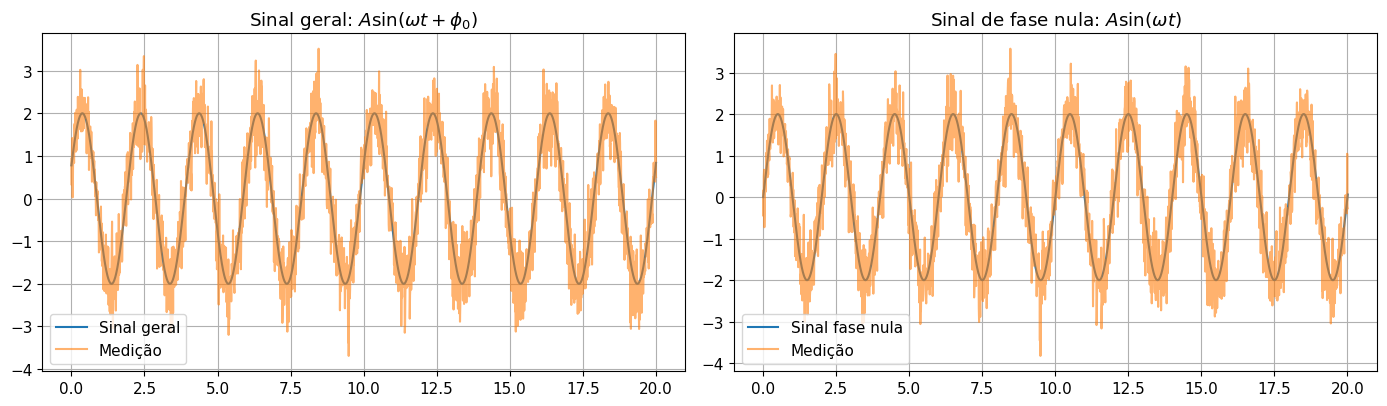

In [ ]:
# Sinal geral (para modelos 1, 2, 3, 4 e 6)
phi_true_g, y_true_g, ydot_true_g = oscillator_true_states_general(
    t, A_true, omega_true, phi0_true
)
z_g = make_measurement(y_true_g, sigma_v, seed=BASE_SEED)

# Sinal de fase nula (para modelo 5)
phi_true_5, y_true_5, ydot_true_5 = oscillator_true_states_zero_phase(
    t, A_true, omega_true
)
z_5 = make_measurement(y_true_5, sigma_v, seed=BASE_SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(t, y_true_g, label="Sinal geral")
axes[0].plot(t, z_g, alpha=0.6, label="Medição")
axes[0].set_title("Sinal geral: $A\\sin(\\omega t + \\phi_0)$")
axes[0].legend()

axes[1].plot(t, y_true_5, label="Sinal de fase nula")
axes[1].plot(t, z_5, alpha=0.6, label="Medição")
axes[1].set_title("Sinal de fase nula: $A\\sin(\\omega t)$")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Implementação dos filtros

- **Modelos 1–4**: implementados com **EKF**
- **Modelos 5–6**: implementados com **Filtro de Kalman linear**

As formulações discretas foram implementadas de forma prática:

- nos modelos em fase (**1 e 2**), a propagação é direta
- nos modelos com dinâmica não linear em $[y,\dot y,\cdot]$ (**3 e 4**), a predição usa Euler explícito de primeira ordem, e a covariância é propagada por linearização local de primeira ordem
- nos modelos lineares (**5 e 6**), a discretização vem do oscilador harmônico

---
#### **Modelos 5 e 6**
- usam a formulação linear do oscilador harmônico
- o estado é escrito em função do sinal e de sua derivada
- a dinâmica e a medição são lineares

O estado é:
- $[\,y,\ \dot y\,]^T$

A medição é:
- $z_k = [\,1\ \ 0\,]x_k + v_k$

Aqui usa-se **Filtro de Kalman clássico** porque:
- a dinâmica e a medição são lineares

A discretização é feita de forma direta, porque:
- a matriz discreta do oscilador pode ser obtida em forma fechada
- isso torna a implementação mais simples

In [ ]:
# Pega um sistema já discretizado e aplica o ciclo de kalman

def run_kf_linear(z, A_d, C, Q, R, x0_hat, P0):
    n = A_d.shape[0]
    xhat_hist = np.zeros((len(z), n))
    P_hist = np.zeros((len(z), n, n))
    innov_hist = np.zeros(len(z))
    xhat = x0_hat.astype(float).copy()
    P = P0.astype(float).copy()

    for k in range(len(z)):
        # predição
        xbar = A_d @ xhat
        M = A_d @ P @ A_d.T + Q
        # correção
        # usa a medição z[k] para corrigir a predição
        S = C @ M @ C.T + R
        K = (M @ C.T) / S
        innov = z[k] - (C @ xbar).item()
        xhat = xbar + K.flatten() * innov
        P = (np.eye(n) - K @ C) @ M
        xhat_hist[k] = xhat
        P_hist[k] = P
        innov_hist[k] = innov

    return {
        "xhat": xhat_hist,
        "P": P_hist,
        "innov": innov_hist,
        "y_est": xhat_hist[:, 0],
        "ydot_est": xhat_hist[:, 1],
    }

# Matriz de transição discreta do oscilador harmônico
def oscillator_Ad(omega, Ts):
    c = np.cos(omega * Ts)
    s = np.sin(omega * Ts)
    return np.array([
        [c, s / omega],
        [-omega * s, c]
    ], dtype=float)

# Executa o Modelo 6
# - monta a matriz A_d do oscilador harmônico discreto
# - define Q e R
# - chama o filtro de kalman (run_kf_linear)
def run_model6_linear(z, omega_known, Ts, x0_hat, P0, q_scale=1e-5, R=R_scalar):
    A_d = oscillator_Ad(omega_known, Ts)
    C = np.array([[1.0, 0.0]])
    Q = q_scale * np.eye(2)
    return run_kf_linear(z, A_d, C, Q, R, np.asarray(x0_hat), np.asarray(P0))

def run_model5_linear(z, omega_known, Ts, x0_hat, P0, q_scale=1e-5, R=R_scalar):
    A_d = oscillator_Ad(omega_known, Ts)
    C = np.array([[1.0, 0.0]])
    Q = q_scale * np.eye(2)
    return run_kf_linear(z, A_d, C, Q, R, np.asarray(x0_hat), np.asarray(P0))

---
#### **Modelos em fase (1 e 2)**

- usam o estado em coordenadas de fase
- a propagação discreta do estado é direta

O estado é:
- **Modelo 1:** $[\,\phi,\ \omega\,]^T$
- **Modelo 2:** $[\,\phi,\ \omega,\ A\,]^T$

A medição é do tipo:
- $z_k = A\sin(\phi_k) + v_k$

Aqui usa-se **EKF** porque:
- a dinâmica discreta é simples
- a **medição é não linear**

A diferença entre os modelos é:
- no **Modelo 1**, a amplitude é conhecida
- no **Modelo 2**, a amplitude também é estimada

In [ ]:
def run_model1_ekf(z, Ts, A_known, x0_hat, P0, q_omega=1e-3, R=R_scalar, wrap_phase_flag=True):
    n = 2
    xhat_hist = np.zeros((len(z), n))
    P_hist = np.zeros((len(z), n, n))
    xhat = np.asarray(x0_hat, dtype=float).copy()  # [phi, omega]
    P = np.asarray(P0, dtype=float).copy()

    Q = np.array([
        [q_omega * Ts**3 / 3.0, q_omega * Ts**2 / 2.0],
        [q_omega * Ts**2 / 2.0, q_omega * Ts]
    ])

    for k in range(len(z)):
        phi, omega = xhat
        # predição exata da dinâmica discreta
        xbar = np.array([phi + Ts * omega, omega], dtype=float)
        if wrap_phase_flag:
            xbar[0] = wrap_to_pi(xbar[0])

        F = np.array([
            [1.0, Ts],
            [0.0, 1.0]
        ])
        M = F @ P @ F.T + Q

        # medição
        phi_b, omega_b = xbar
        h = A_known * np.sin(phi_b)
        H = np.array([[A_known * np.cos(phi_b), 0.0]])
        S = (H @ M @ H.T).item() + R
        K = (M @ H.T) / S
        innov = z[k] - h
        xhat = xbar + K.flatten() * innov
        if wrap_phase_flag:
            xhat[0] = wrap_to_pi(xhat[0])
        P = (np.eye(n) - K @ H) @ M
        xhat_hist[k] = xhat
        P_hist[k] = P

    phi_est = xhat_hist[:, 0]
    omega_est = xhat_hist[:, 1]
    y_est = A_known * np.sin(phi_est)

    return {
        "xhat": xhat_hist,
        "P": P_hist,
        "phi_est": phi_est,
        "omega_est": omega_est,
        "A_est": np.full(len(z), A_known),
        "y_est": y_est,
    }

def run_model2_ekf(z, Ts, x0_hat, P0, q_omega=1e-3, q_A=1e-4, R=R_scalar, wrap_phase_flag=True):
    n = 3
    xhat_hist = np.zeros((len(z), n))
    P_hist = np.zeros((len(z), n, n))
    xhat = np.asarray(x0_hat, dtype=float).copy()  # [phi, omega, A]
    P = np.asarray(P0, dtype=float).copy()

    Q = np.array([
        [q_omega * Ts**3 / 3.0, q_omega * Ts**2 / 2.0, 0.0],
        [q_omega * Ts**2 / 2.0, q_omega * Ts, 0.0],
        [0.0, 0.0, q_A * Ts]
    ])

    for k in range(len(z)):
        phi, omega, A = xhat
        xbar = np.array([phi + Ts * omega, omega, A], dtype=float)
        if wrap_phase_flag:
            xbar[0] = wrap_to_pi(xbar[0])

        F = np.array([
            [1.0, Ts, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0]
        ])
        
        M = F @ P @ F.T + Q
        phi_b, omega_b, A_b = xbar
        h = A_b * np.sin(phi_b)
        H = np.array([[A_b * np.cos(phi_b), 0.0, np.sin(phi_b)]])
        S = (H @ M @ H.T).item() + R
        K = (M @ H.T) / S
        innov = z[k] - h
        xhat = xbar + K.flatten() * innov
        if wrap_phase_flag:
            xhat[0] = wrap_to_pi(xhat[0])
        P = (np.eye(n) - K @ H) @ M
        xhat_hist[k] = xhat
        P_hist[k] = P

    phi_est = xhat_hist[:, 0]
    omega_est = xhat_hist[:, 1]
    A_est = xhat_hist[:, 2]
    y_est = A_est * np.sin(phi_est)

    return {
        "xhat": xhat_hist,
        "P": P_hist,
        "phi_est": phi_est,
        "omega_est": omega_est,
        "A_est": A_est,
        "y_est": y_est,
    }

---
#### **Modelos não lineares em $[y,\dot y,\cdot]$ (3 e 4)**

- ambos representam a senoide diretamente no espaço $[y,\dot y,\cdot]$
- possuem dinâmica contínua não linear
- exigem discretização da dinâmica e linearização local

O estado é da forma:
- $[\,y,\ \dot y,\ \theta\,]^T$
- onde o terceiro estado depende do modelo

Aqui se usa **EKF** porque:
- a **dinâmica é não linear**
- a correção usa jacobiana local

In [ ]:
def f_model3(x):
    y, ydot, omega = x
    return np.array([ydot, -(omega**2) * y, 0.0], dtype=float)

def jac_model3(x):
    y, ydot, omega = x
    return np.array([
        [0.0, 1.0, 0.0],
        [-(omega**2), 0.0, -2.0 * omega * y],
        [0.0, 0.0, 0.0]
    ], dtype=float)

def run_model3_ekf(z, Ts, x0_hat, P0, q_state=(1e-6, 1e-5, 1e-3), R=R_scalar):
    n = 3
    xhat_hist = np.zeros((len(z), n))
    P_hist = np.zeros((len(z), n, n))
    xhat = np.asarray(x0_hat, dtype=float).copy()  # [y, ydot, omega]
    P = np.asarray(P0, dtype=float).copy()
    Q = np.diag(q_state)
    H = np.array([[1.0, 0.0, 0.0]])

    for k in range(len(z)):
        xbar = euler_step(f_model3, xhat, Ts)
        F = np.eye(n) + Ts * jac_model3(xhat)
        M = F @ P @ F.T + Q
        h = xbar[0]
        S = (H @ M @ H.T).item() + R
        K = (M @ H.T) / S
        innov = z[k] - h
        xhat = xbar + K.flatten() * innov
        P = (np.eye(n) - K @ H) @ M
        xhat_hist[k] = xhat
        P_hist[k] = P

    return {
        "xhat": xhat_hist,
        "P": P_hist,
        "y_est": xhat_hist[:, 0],
        "ydot_est": xhat_hist[:, 1],
        "omega_est": xhat_hist[:, 2],
    }


def f_model4(x):
    y, ydot, mu = x
    return np.array([ydot, -mu * y, 0.0], dtype=float)

def jac_model4(x):
    y, ydot, mu = x
    return np.array([
        [0.0, 1.0, 0.0],
        [-mu, 0.0, -y],
        [0.0, 0.0, 0.0]
    ], dtype=float)

def run_model4_ekf(z, Ts, x0_hat, P0, q_state=(1e-6, 1e-5, 1e-3), R=R_scalar):
    n = 3
    xhat_hist = np.zeros((len(z), n))
    P_hist = np.zeros((len(z), n, n))

    xhat = np.asarray(x0_hat, dtype=float).copy()  # [y, ydot, mu]
    P = np.asarray(P0, dtype=float).copy()
    Q = np.diag(q_state)
    H = np.array([[1.0, 0.0, 0.0]])

    for k in range(len(z)):
        xbar = euler_step(f_model4, xhat, Ts)
        F = np.eye(n) + Ts * jac_model4(xhat)
        M = F @ P @ F.T + Q
        h = xbar[0]
        S = (H @ M @ H.T).item() + R
        K = (M @ H.T) / S
        innov = z[k] - h
        xhat = xbar + K.flatten() * innov
        P = (np.eye(n) - K @ H) @ M
        xhat_hist[k] = xhat
        P_hist[k] = P

    mu_est = xhat_hist[:, 2]
    omega_mag_est = np.sqrt(np.clip(mu_est, 0.0, None))

    return {
        "xhat": xhat_hist,
        "P": P_hist,
        "y_est": xhat_hist[:, 0],
        "ydot_est": xhat_hist[:, 1],
        "mu_est": mu_est,
        "omega_mag_est": omega_mag_est,
    }

---
## Configuração do caso base

O caso base é um cenário geral para comparar os modelos, com::

- amplitude constante
- frequência constante
- ruído de medição gaussiano
- condição inicial fixa para cada filtro

A análise principal será focada em:

1. **capacidade de reconstrução do sinal**
2. **capacidade de estimar parâmetros** quando o modelo permitir
3. **sensibilidade à inicialização**

In [ ]:
# estados verdadeiros iniciais do sinal geral
y0_true_g = y_true_g[0]
ydot0_true_g = ydot_true_g[0]

# estados verdadeiros iniciais do sinal fase nula (modelo 5)
y0_true_5 = y_true_5[0]
ydot0_true_5 = ydot_true_5[0]

# x0_m1 até x0_m6 - chutes iniciais de cada filtro
# P0_m1 até P0_m6 - incerteza inicial para cada filtro
# res_m1 até res_m6 - resultados do caso base para cada modelo

x0_m1 = np.array([0.0, 1.20 * omega_true])
P0_m1 = np.diag([0.5**2, 0.8**2])
x0_m2 = np.array([0.0, 1.20 * omega_true, 1.5])
P0_m2 = np.diag([0.5**2, 0.8**2, 0.8**2])
x0_m3 = np.array([0.0, 0.0, 1.20 * omega_true])
P0_m3 = np.diag([1.0**2, 1.5**2, 0.8**2])
x0_m4 = np.array([0.0, 0.0, (1.20 * omega_true) ** 2])
P0_m4 = np.diag([1.0**2, 1.5**2, (2.0 * omega_true) ** 2])
x0_m5 = np.array([0.0, 0.70 * ydot0_true_5])
P0_m5 = np.diag([0.8**2, (2.0)**2])
x0_m6 = np.array([0.0, 0.0])
P0_m6 = np.diag([1.0**2, (3.0)**2])

# Execução do caso base
res_m1 = run_model1_ekf(z_g, Ts, A_true, x0_m1, P0_m1, q_omega=1e-3, R=R_scalar)
res_m2 = run_model2_ekf(z_g, Ts, x0_m2, P0_m2, q_omega=1e-3, q_A=1e-4, R=R_scalar)
res_m3 = run_model3_ekf(z_g, Ts, x0_m3, P0_m3, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar)
res_m4 = run_model4_ekf(z_g, Ts, x0_m4, P0_m4, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar)
res_m5 = run_model5_linear(z_5, omega_true, Ts, x0_m5, P0_m5, q_scale=1e-5, R=R_scalar)
res_m6 = run_model6_linear(z_g, omega_true, Ts, x0_m6, P0_m6, q_scale=1e-5, R=R_scalar)

---
## resultados do caso base

Para cada modelo, tem-se:
- a classe do filtro
- o erro da medição ruidosa em relação ao sinal verdadeiro
- o erro de reconstrução do sinal
- o erro de estimação de parâmetros, quando aplicável

Nessa tabela:
- **RMSE sinal** - mede a qualidade da reconstrução
- **RMSE frequência** - só aparece nos modelos que estimam frequência
- **RMSE amplitude** - só aparece no modelo que estima amplitude

In [ ]:
base_rows = []

base_rows.append({
    "Modelo": "Modelo 1 (EKF, A conhecida)",
    "Classe": "Não linear",
    "RMSE medição": rmse(y_true_g, z_g),
    "RMSE sinal": rmse(y_true_g, res_m1["y_est"]),
    "RMSE frequência": rmse(np.full(N, omega_true), res_m1["omega_est"]),
    "RMSE amplitude": np.nan
})

base_rows.append({
    "Modelo": "Modelo 2 (EKF, A estimada)",
    "Classe": "Não linear",
    "RMSE medição": rmse(y_true_g, z_g),
    "RMSE sinal": rmse(y_true_g, res_m2["y_est"]),
    "RMSE frequência": rmse(np.full(N, omega_true), res_m2["omega_est"]),
    "RMSE amplitude": rmse(np.full(N, A_true), res_m2["A_est"])
})

base_rows.append({
    "Modelo": "Modelo 3 (EKF em [y, ydot, ω])",
    "Classe": "Não linear",
    "RMSE medição": rmse(y_true_g, z_g),
    "RMSE sinal": rmse(y_true_g, res_m3["y_est"]),
    "RMSE frequência": rmse(np.full(N, omega_true), res_m3["omega_est"]),
    "RMSE amplitude": np.nan
})

base_rows.append({
    "Modelo": "Modelo 4 (EKF em [y, ydot, μ])",
    "Classe": "Não linear",
    "RMSE medição": rmse(y_true_g, z_g),
    "RMSE sinal": rmse(y_true_g, res_m4["y_est"]),
    "RMSE frequência": rmse(np.full(N, abs(omega_true)), res_m4["omega_mag_est"]),
    "RMSE amplitude": np.nan
})

base_rows.append({
    "Modelo": "Modelo 5 (KF linear, fase nula)",
    "Classe": "Linear",
    "RMSE medição": rmse(y_true_5, z_5),
    "RMSE sinal": rmse(y_true_5, res_m5["y_est"]),
    "RMSE frequência": np.nan,
    "RMSE amplitude": np.nan
})

base_rows.append({
    "Modelo": "Modelo 6 (KF linear, fase livre)",
    "Classe": "Linear",
    "RMSE medição": rmse(y_true_g, z_g),
    "RMSE sinal": rmse(y_true_g, res_m6["y_est"]),
    "RMSE frequência": np.nan,
    "RMSE amplitude": np.nan
})

base_df = pd.DataFrame(base_rows)
table_display(base_df, sort_by="RMSE sinal")

,Modelo,Classe,RMSE medição,RMSE sinal,RMSE frequência,RMSE amplitude
0,"Modelo 5 (KF linear, fase nula)",Linear,0.501489,0.033470,NaN,NaN
1,"Modelo 6 (KF linear, fase livre)",Linear,0.501489,0.038634,NaN,NaN
2,"Modelo 1 (EKF, A conhecida)",Não linear,0.501489,0.056949,0.109615,NaN
3,"Modelo 2 (EKF, A estimada)",Não linear,0.501489,0.062736,0.117187,0.046329
4,"Modelo 3 (EKF em [y, ydot, ω])",Não linear,0.501489,0.127327,0.175665,NaN
5,"Modelo 4 (EKF em [y, ydot, μ])",Não linear,0.501489,0.219452,0.148530,NaN


### Leitura do caso base

Analisa-se:
- quais modelos **reconstroem melhor o sinal**
- quais modelos **estimam frequência** de forma mais estável

Em específico:
- o **Modelo 4** estima $\mu=\omega^2$, assim ele fornece a **magnitude** da frequência, e não o sinal de $\omega$
- o **Modelo 5** é um caso linear especializado
- o **Modelo 6** é o caso linear mais geral

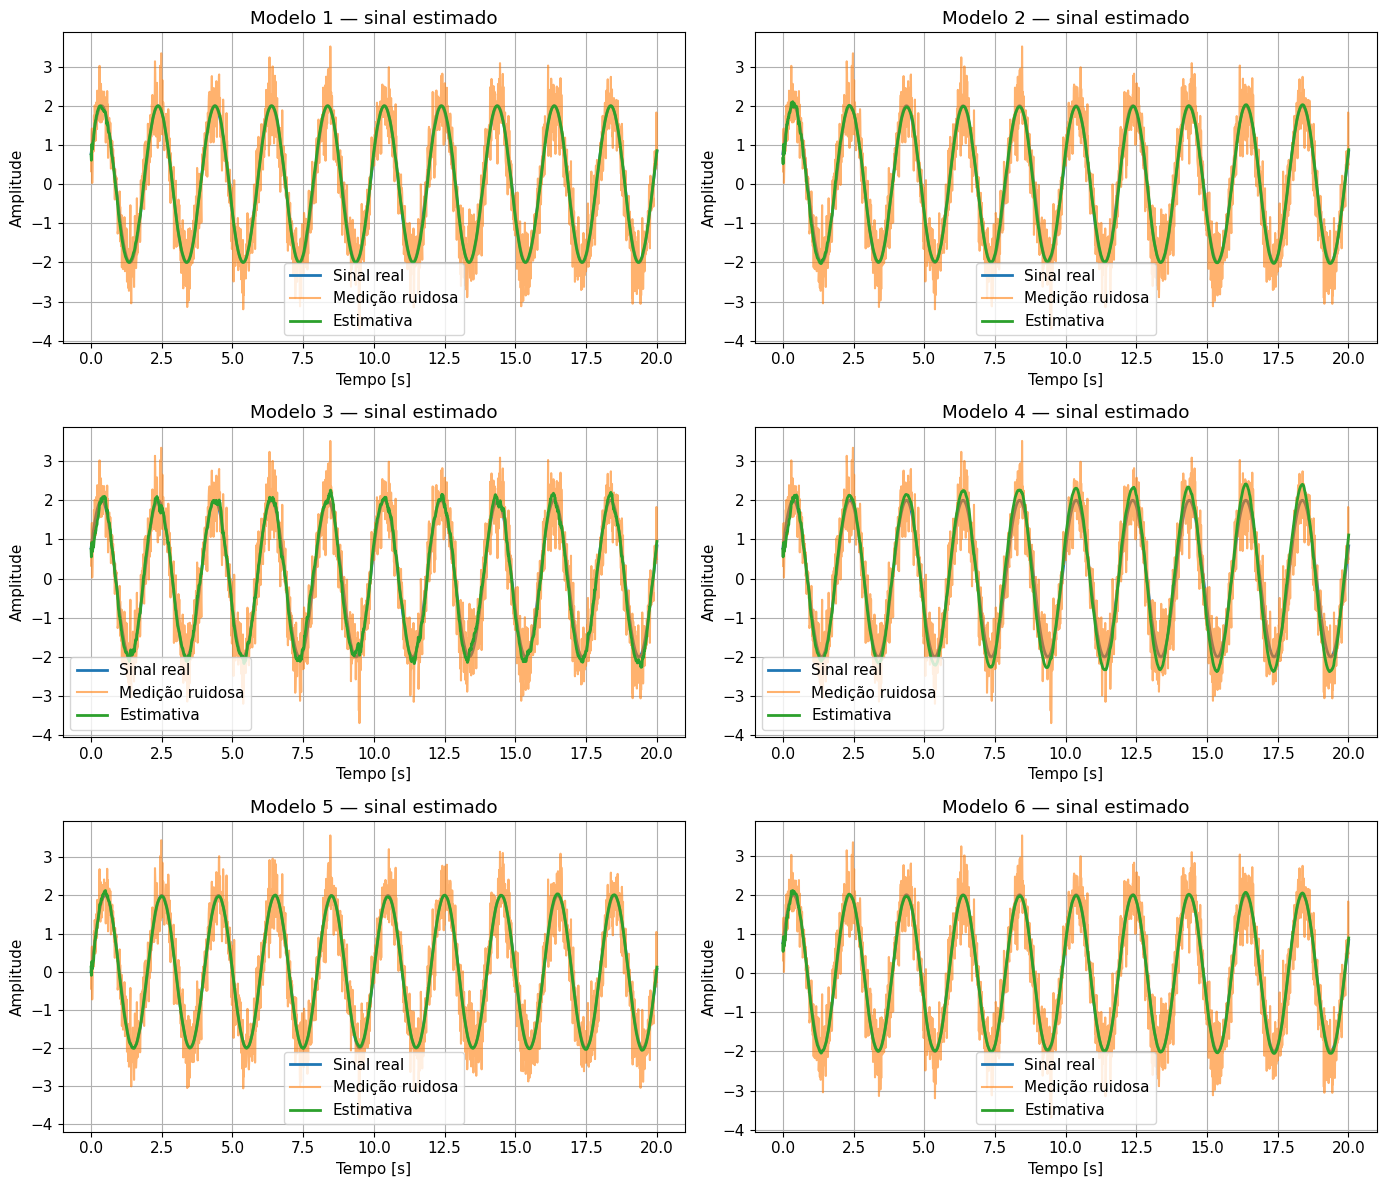

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plot_signal(axes[0, 0], t, y_true_g, z_g, res_m1["y_est"], "Modelo 1 — sinal estimado")
plot_signal(axes[0, 1], t, y_true_g, z_g, res_m2["y_est"], "Modelo 2 — sinal estimado")
plot_signal(axes[1, 0], t, y_true_g, z_g, res_m3["y_est"], "Modelo 3 — sinal estimado")
plot_signal(axes[1, 1], t, y_true_g, z_g, res_m4["y_est"], "Modelo 4 — sinal estimado")
plot_signal(axes[2, 0], t, y_true_5, z_5, res_m5["y_est"], "Modelo 5 — sinal estimado")
plot_signal(axes[2, 1], t, y_true_g, z_g, res_m6["y_est"], "Modelo 6 — sinal estimado")

plt.tight_layout()
plt.show()

## Estimação dos parâmetros

Convergência para estimação dos parâmetros nos modelos que permitem a estimação

São exibidos:
- a **frequência estimada** nos Modelos 1 a 4
- a **amplitude estimada** no Modelo 2

Aqui conseguimos observar:
- a velocidade de convergência
- oscilações transitórias
- estabilidade da estimação ao longo do tempo

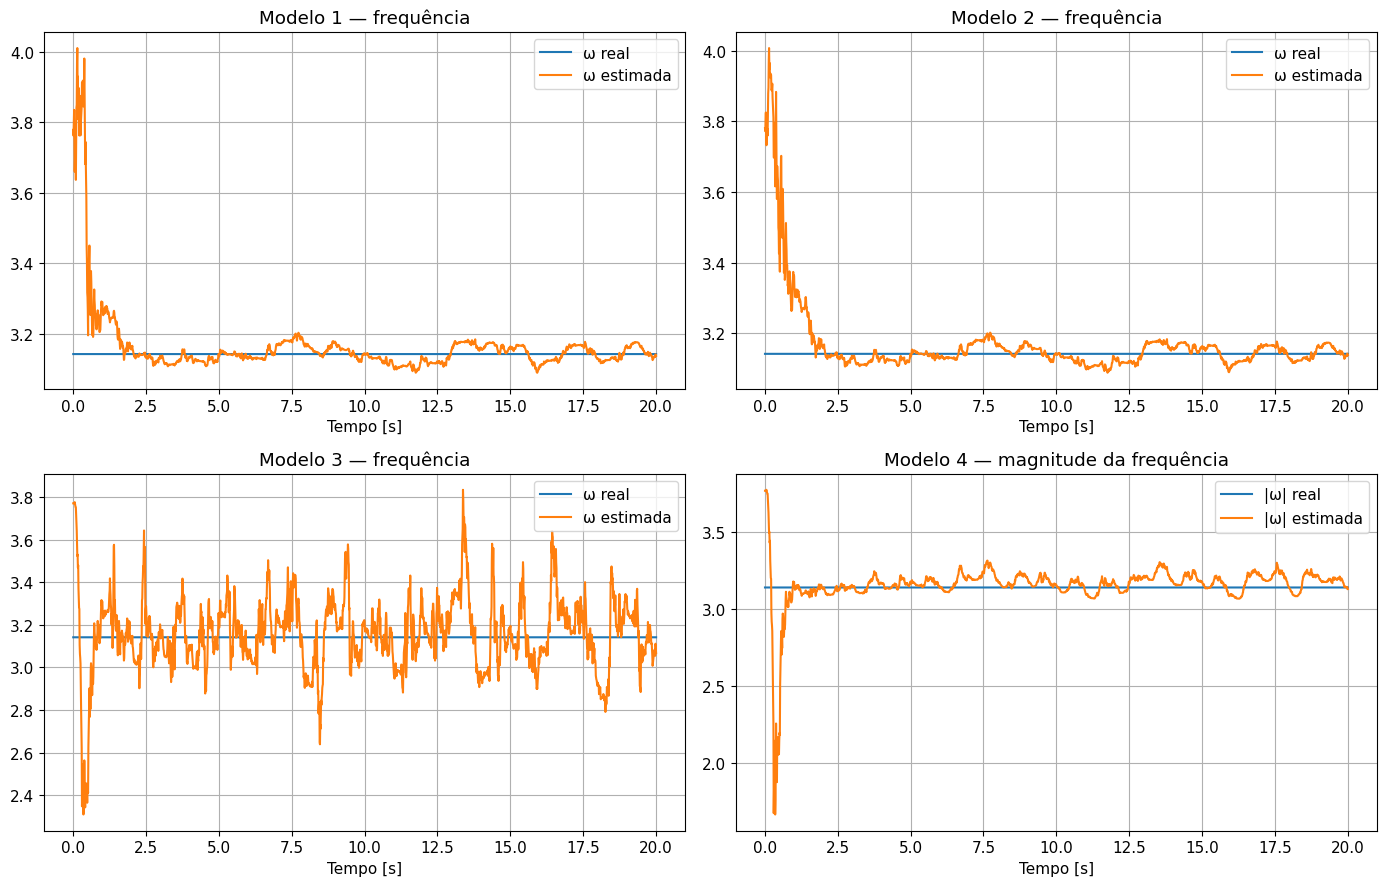

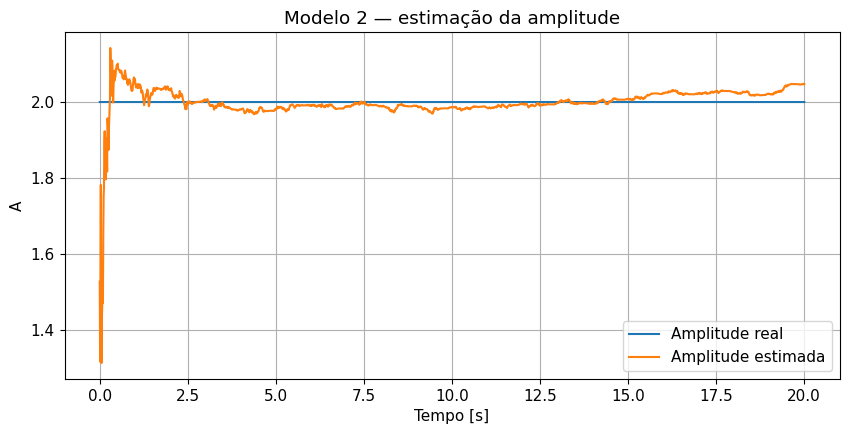

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(t, np.full(N, omega_true), label="ω real")
axes[0, 0].plot(t, res_m1["omega_est"], label="ω estimada")
axes[0, 0].set_title("Modelo 1 — frequência")

axes[0, 1].plot(t, np.full(N, omega_true), label="ω real")
axes[0, 1].plot(t, res_m2["omega_est"], label="ω estimada")
axes[0, 1].set_title("Modelo 2 — frequência")

axes[1, 0].plot(t, np.full(N, omega_true), label="ω real")
axes[1, 0].plot(t, res_m3["omega_est"], label="ω estimada")
axes[1, 0].set_title("Modelo 3 — frequência")

axes[1, 1].plot(t, np.full(N, abs(omega_true)), label="|ω| real")
axes[1, 1].plot(t, res_m4["omega_mag_est"], label="|ω| estimada")
axes[1, 1].set_title("Modelo 4 — magnitude da frequência")

for ax in axes.ravel():
    ax.set_xlabel("Tempo [s]")
    ax.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(t, np.full(N, A_true), label="Amplitude real")
plt.plot(t, res_m2["A_est"], label="Amplitude estimada")
plt.title("Modelo 2 — estimação da amplitude")
plt.xlabel("Tempo [s]")
plt.ylabel("A")
plt.legend()
plt.show()

## Sensibilidade à inicialização

A ideia é:
- fazer um chute para valores iniciais
- aanlisar o impacto no RMSE do sinal e da frequência/amplitude, quando aplicável

Aplica-se três níveis de inicialização:
- **bom**: chute próximo do estado verdadeiro
- **moderado**: chute razoável, mas com erro perceptível
- **ruim**: chute distante do estado verdadeiro

Os chutes não são iguais entre todos os modelos, porque cada estrutura de estados é diferente

In [ ]:
scenarios = {
    "Modelo 1": {
        "bom": np.array([phi0_true, 0.95 * omega_true]),
        "moderado": np.array([0.0, 1.30 * omega_true]),
        "ruim": np.array([2.0, -0.80 * omega_true]),
    },
    "Modelo 2": {
        "bom": np.array([phi0_true, 0.95 * omega_true, 1.90]),
        "moderado": np.array([0.0, 1.30 * omega_true, 1.2]),
        "ruim": np.array([2.0, -0.80 * omega_true, 4.0]),
    },
    "Modelo 3": {
        "bom": np.array([0.95 * y0_true_g, 0.95 * ydot0_true_g, 0.95 * omega_true]),
        "moderado": np.array([0.0, 0.0, 1.30 * omega_true]),
        "ruim": np.array([0.0, 0.0, -0.80 * omega_true]),
    },
    "Modelo 4": {
        "bom": np.array([0.95 * y0_true_g, 0.95 * ydot0_true_g, 0.95 * omega_true**2]),
        "moderado": np.array([0.0, 0.0, 1.30 * omega_true**2]),
        "ruim": np.array([0.0, 0.0, 0.10 * omega_true**2]),
    },
    "Modelo 5": {
        "bom": np.array([0.0, 0.95 * ydot0_true_5]),
        "moderado": np.array([0.0, 0.0]),
        "ruim": np.array([1.5, -0.50 * ydot0_true_5]),
    },
    "Modelo 6": {
        "bom": np.array([0.95 * y0_true_g, 0.95 * ydot0_true_g]),
        "moderado": np.array([0.0, 0.0]),
        "ruim": np.array([-1.5, -2.0]),
    }
}

results_init = []

for level in ["bom", "moderado", "ruim"]:
    # modelo 1
    r = run_model1_ekf(z_g, Ts, A_true, scenarios["Modelo 1"][level], P0_m1, q_omega=1e-3, R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 1",
        "Classe": "Não linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_g, r["y_est"]),
        "RMSE frequência": rmse(np.full(N, omega_true), r["omega_est"]),
        "RMSE amplitude": np.nan
    })

    # modelo 2
    r = run_model2_ekf(z_g, Ts, scenarios["Modelo 2"][level], P0_m2, q_omega=1e-3, q_A=1e-4, R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 2",
        "Classe": "Não linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_g, r["y_est"]),
        "RMSE frequência": rmse(np.full(N, omega_true), r["omega_est"]),
        "RMSE amplitude": rmse(np.full(N, A_true), r["A_est"])
    })

    # modelo 3
    r = run_model3_ekf(z_g, Ts, scenarios["Modelo 3"][level], P0_m3, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 3",
        "Classe": "Não linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_g, r["y_est"]),
        "RMSE frequência": rmse(np.full(N, omega_true), r["omega_est"]),
        "RMSE amplitude": np.nan
    })

    # modelo 4
    r = run_model4_ekf(z_g, Ts, scenarios["Modelo 4"][level], P0_m4, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 4",
        "Classe": "Não linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_g, r["y_est"]),
        "RMSE frequência": rmse(np.full(N, abs(omega_true)), r["omega_mag_est"]),
        "RMSE amplitude": np.nan
    })

    # Modelo 5
    r = run_model5_linear(z_5, omega_true, Ts, scenarios["Modelo 5"][level], P0_m5, q_scale=1e-5, R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 5",
        "Classe": "Linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_5, r["y_est"]),
        "RMSE frequência": np.nan,
        "RMSE amplitude": np.nan
    })

    # Modelo 6
    r = run_model6_linear(z_g, omega_true, Ts, scenarios["Modelo 6"][level], P0_m6, q_scale=1e-5, R=R_scalar)
    results_init.append({
        "Modelo": "Modelo 6",
        "Classe": "Linear",
        "Cenário": level,
        "RMSE sinal": rmse(y_true_g, r["y_est"]),
        "RMSE frequência": np.nan,
        "RMSE amplitude": np.nan
    })

init_df = pd.DataFrame(results_init)
# table_display(init_df)

In [ ]:
pivot_signal = init_df.pivot(index="Modelo", columns="Cenário", values="RMSE sinal")
pivot_freq = init_df.pivot(index="Modelo", columns="Cenário", values="RMSE frequência")

print("RMSE do sinal por cenário de inicialização")
display(pivot_signal)

print("RMSE de frequência (quando aplicável)")
display(pivot_freq)

RMSE do sinal por cenário de inicialização


Cenário,bom,moderado,ruim
Modelo,,,
Modelo 1,0.055368,0.057809,0.056685
Modelo 2,0.061453,0.064354,0.068317
Modelo 3,0.123485,0.127699,0.127250
Modelo 4,0.216881,0.219549,0.222477
Modelo 5,0.033345,0.043228,0.056625
Modelo 6,0.034367,0.038634,0.044368


RMSE de frequência (quando aplicável)


Cenário,bom,moderado,ruim
Modelo,,,
Modelo 1,0.041749,0.142656,6.277572
Modelo 2,0.040719,0.165554,6.274374
Modelo 3,0.150862,0.181715,6.284126
Modelo 4,0.066944,0.159782,0.449137
Modelo 5,NaN,NaN,NaN
Modelo 6,NaN,NaN,NaN


### Gráfico - Desempenho: sensibilidade à inicialização

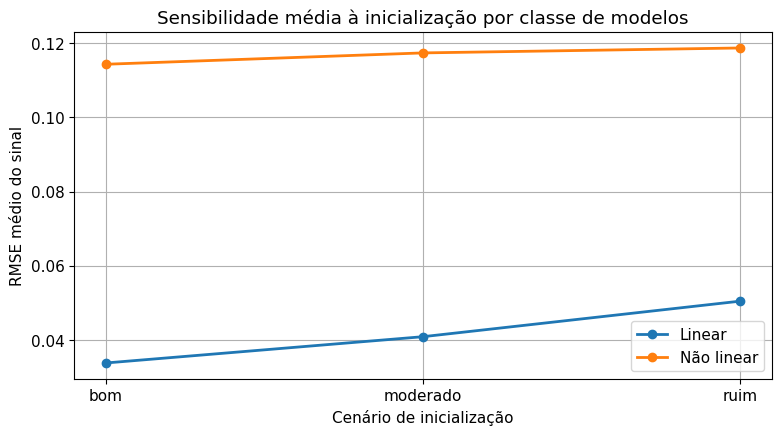

In [ ]:
mean_by_group = init_df.groupby(["Classe", "Cenário"])["RMSE sinal"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
for classe, dfc in mean_by_group.groupby("Classe"):
    ax.plot(dfc["Cenário"], dfc["RMSE sinal"], marker="o", linewidth=2, label=classe)

ax.set_title("Sensibilidade média à inicialização por classe de modelos")
ax.set_ylabel("RMSE médio do sinal")
ax.set_xlabel("Cenário de inicialização")
ax.legend()
plt.show()

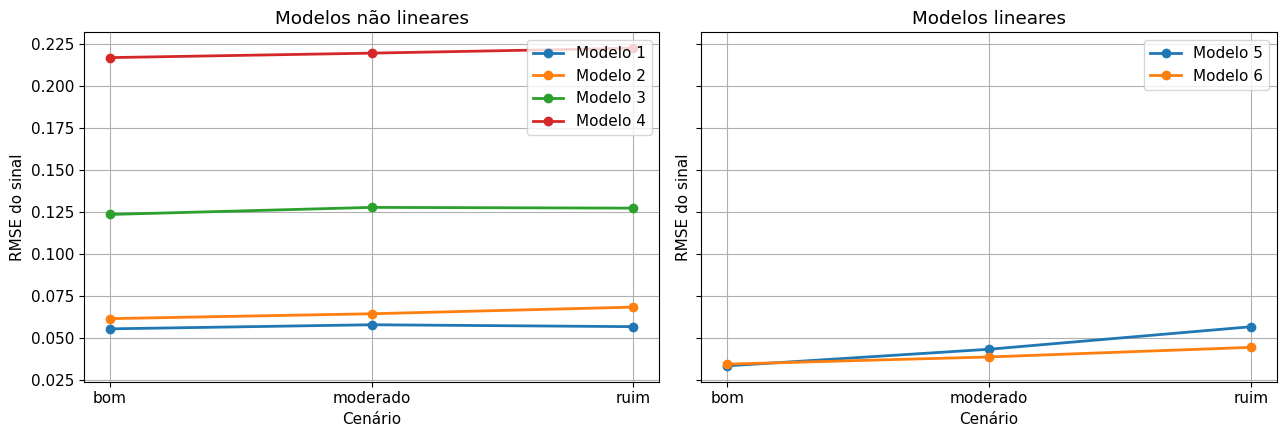

In [ ]:
nonlinear_models = ["Modelo 1", "Modelo 2", "Modelo 3", "Modelo 4"]
linear_models = ["Modelo 5", "Modelo 6"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for mdl in nonlinear_models:
    tmp = init_df[init_df["Modelo"] == mdl]
    axes[0].plot(tmp["Cenário"], tmp["RMSE sinal"], marker="o", linewidth=2, label=mdl)

for mdl in linear_models:
    tmp = init_df[init_df["Modelo"] == mdl]
    axes[1].plot(tmp["Cenário"], tmp["RMSE sinal"], marker="o", linewidth=2, label=mdl)

axes[0].set_title("Modelos não lineares")
axes[1].set_title("Modelos lineares")
for ax in axes:
    ax.set_xlabel("Cenário")
    ax.set_ylabel("RMSE do sinal")
    ax.legend()

plt.tight_layout()
plt.show()

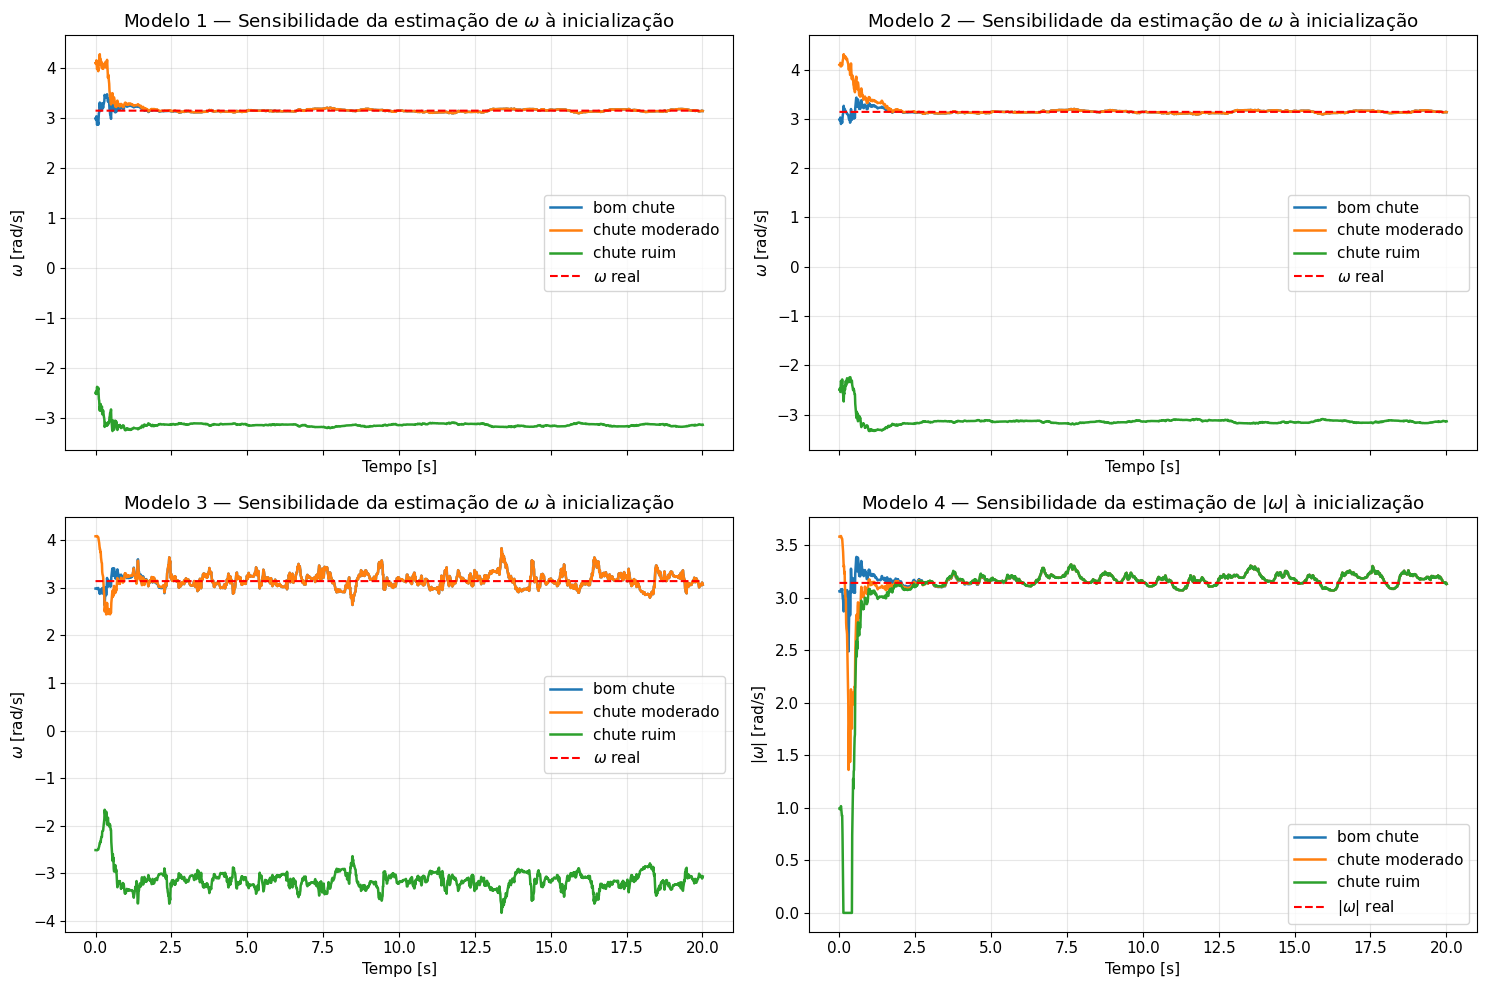

In [ ]:
# Sensibilidade da estimação da frequência à inicialização
# Modelos 1, 2 e 3: plota ω estimado
# Modelo 4: plota a estimação de |ω|, pois tem-se μ = ω²

scenario_labels = [
    ("bom", "bom chute"),
    ("moderado", "chute moderado"),
    ("ruim", "chute ruim"),
]

freq_sensitivity_specs = [
    {
        "name": "Modelo 1",
        "runner": lambda x0: run_model1_ekf(
            z_g, Ts, A_true, x0, P0_m1, q_omega=1e-3, R=R_scalar
        ),
        "scenarios": scenarios["Modelo 1"],
        "key": "omega_est",
        "y_true_plot": np.full_like(t, omega_true, dtype=float),
        "y_label": r"$\omega$ [rad/s]",
        "title": r"Modelo 1 — Sensibilidade da estimação de $\omega$ à inicialização",
        "legend_true": r"$\omega$ real",
    },
    {
        "name": "Modelo 2",
        "runner": lambda x0: run_model2_ekf(
            z_g, Ts, x0, P0_m2, q_omega=1e-3, q_A=1e-4, R=R_scalar
        ),
        "scenarios": scenarios["Modelo 2"],
        "key": "omega_est",
        "y_true_plot": np.full_like(t, omega_true, dtype=float),
        "y_label": r"$\omega$ [rad/s]",
        "title": r"Modelo 2 — Sensibilidade da estimação de $\omega$ à inicialização",
        "legend_true": r"$\omega$ real",
    },
    {
        "name": "Modelo 3",
        "runner": lambda x0: run_model3_ekf(
            z_g, Ts, x0, P0_m3, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar
        ),
        "scenarios": scenarios["Modelo 3"],
        "key": "omega_est",
        "y_true_plot": np.full_like(t, omega_true, dtype=float),
        "y_label": r"$\omega$ [rad/s]",
        "title": r"Modelo 3 — Sensibilidade da estimação de $\omega$ à inicialização",
        "legend_true": r"$\omega$ real",
    },
    {
        "name": "Modelo 4",
        "runner": lambda x0: run_model4_ekf(
            z_g, Ts, x0, P0_m4, q_state=(1e-6, 1e-5, 2e-3), R=R_scalar
        ),
        "scenarios": scenarios["Modelo 4"],
        "key": "omega_mag_est",
        "y_true_plot": np.full_like(t, abs(omega_true), dtype=float),
        "y_label": r"$|\omega|$ [rad/s]",
        "title": r"Modelo 4 — Sensibilidade da estimação de $|\omega|$ à inicialização",
        "legend_true": r"$|\omega|$ real",
    },
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

for ax, spec in zip(axes, freq_sensitivity_specs):
    for level, label in scenario_labels:
        res = spec["runner"](spec["scenarios"][level])
        ax.plot(t, res[spec["key"]], label=label, linewidth=1.8)

    ax.plot(
        t,
        spec["y_true_plot"],
        "r--",
        linewidth=1.5,
        label=spec["legend_true"],
    )

    ax.set_title(spec["title"])
    ax.set_xlabel("Tempo [s]")
    ax.set_ylabel(spec["y_label"])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusão

| Modelagem | Conclusão |
|---|---|
| Separação | Modelos 1–4 são não lineares; Modelos 5–6 são lineares |
| Modelos lineares | São adequados quando a frequência é conhecida e o foco é a reconstrução do sinal |
| Modelos não lineares | Permitem estimar frequência e, em alguns casos, amplitude, mas tendem a ser mais sensíveis à inicialização |
| Modelo 2 | É o mais rico parametricamente, pois estima fase, frequência e amplitude |
| Modelo 4 | Estima \(\mu = \omega^2\), portanto recupera a magnitude da frequência, mas não representa diretamente o sinal |
| Modelo 5 | É um caso linear associado à senoide com fase nula |
| Modelo 6 | É a formulação linear mais geral dentre os modelos lineares |